In [22]:
from rdkit import Chem

smiles = "CC1=NN(C=C1)C2=C(C=C(C=C2)Cl)C(=O)N" #это в чатгпт
mol = Chem.MolFromSmiles(smiles)

if mol:
    mol_no_h = Chem.RemoveHs(mol)
    
    canonical_smiles = Chem.MolToSmiles(mol_no_h, isomericSmiles=False, canonical=True)
    
    print(f"Original:  {smiles}")
    print(f"Canonical: {canonical_smiles}")
else:
    print("Ошибка в SMILES!")

Original:  CC1=NN(C=C1)C2=C(C=C(C=C2)Cl)C(=O)N
Canonical: Cc1ccn(-c2ccc(Cl)cc2C(N)=O)n1


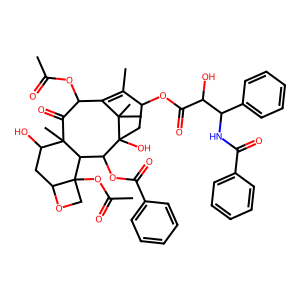

In [14]:
from rdkit.Chem import Draw

smiles = 'CC(=O)OC1C(=O)C2(C)C(O)CC3OCC3(OC(C)=O)C2C(OC(=O)c2ccccc2)C2(O)CC(OC(=O)C(O)C(NC(=O)c3ccccc3)c3ccccc3)C(C)=C1C2(C)C'
mol = Chem.MolFromSmiles(smiles, sanitize=True)
m = Draw.MolToImage(mol)
m

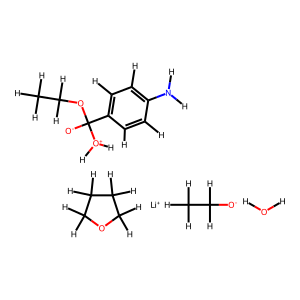

In [27]:
from rdkit.Chem import Draw

smiles = '[H][C]([H])([H])[C]([H])([H])[O-].[H][C]1([H])[O][C]([H])([H])[C]([H])([H])[C]1([H])[H].[H][O][H].[H][c]1[c]([H])[c]([C]([O-])([O][C]([H])([H])[C]([H])([H])[H])[O+]([H])[H])[c]([H])[c]([H])[c]1[N]([H])[H].[Li+]'
mol = Chem.MolFromSmiles(smiles, sanitize=False)
m = Draw.MolToImage(mol)
m

[23:42:23] WARNING: not removing hydrogen atom without neighbors
[23:42:23] WARNING: not removing hydrogen atom without neighbors
[23:42:23] WARNING: not removing hydrogen atom without neighbors
[23:42:23] WARNING: not removing hydrogen atom without neighbors
[23:42:23] WARNING: not removing hydrogen atom without neighbors
[23:42:23] WARNING: not removing hydrogen atom without neighbors
[23:42:23] WARNING: not removing hydrogen atom without neighbors
[23:42:23] WARNING: not removing hydrogen atom without neighbors
[23:42:23] WARNING: not removing hydrogen atom without neighbors
[23:42:23] WARNING: not removing hydrogen atom without neighbors
[23:42:23] WARNING: not removing hydrogen atom without neighbors
[23:42:23] WARNING: not removing hydrogen atom without neighbors
[23:42:23] WARNING: not removing hydrogen atom without neighbors
[23:42:23] WARNING: not removing hydrogen atom without neighbors
[23:42:23] WARNING: not removing hydrogen atom without neighbors
[23:42:23] WARNING: not r

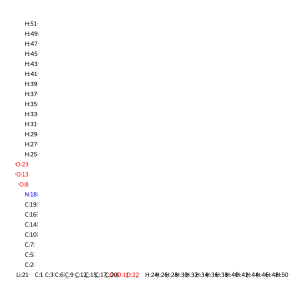

In [26]:
smiles = '[C:1].[C:2].[C:3].[O:4].[C:5].[C:6].[C:7].[O:8].[C:9].[C:10].[O:11].[C:12].[O:13].[C:14].[C:15].[C:16].[C:17].[N:18].[C:19].[C:20].[Li:21].[O:22].[O:23].[H:24].[H:25].[H:26].[H:27].[H:28].[H:29].[H:30].[H:31].[H:32].[H:33].[H:34].[H:35].[H:36].[H:37].[H:38].[H:39].[H:40].[H:41].[H:42].[H:43].[H:44].[H:45].[H:46].[H:47].[H:48].[H:49].[H:50].[H:51]'
mol = Chem.MolFromSmiles(smiles)
m = Draw.MolToImage(mol)
m

In [17]:
from rdkit import Chem

def prepare_for_flower_gpt(input_string): #это из чатагпт преобразуем для входа в фловер
    smi = input_string.replace('>>', '.')
    
    mol = Chem.MolFromSmiles(smi)
    
    if mol:
        mol = Chem.AddHs(mol, explicitOnly=False)
        try:
            Chem.Kekulize(mol, clearAromaticFlags=True)
        except:
            pass 
            
        for idx, atom in enumerate(mol.GetAtoms()):
            atom.SetAtomMapNum(idx + 1)
        
        mapped_smi = Chem.MolToSmiles(mol, isomericSmiles=False, allHsExplicit=True, kekuleSmiles=True)
        
        final_string = f"{mapped_smi}>>{mapped_smi}|1"
        print(final_string)
    else:
        return f"Error: Invalid SMILES string '{input_string}'"

In [25]:
prepare_for_flower_gpt('CC1=NN(C=C1)C2=C(C=C(C=C2)Cl)C(=O)N')

[C:1]([C:2]1=[N:3][N:4]([C:7]2=[C:8]([C:14](=[O:15])[N:16]([H:25])[H:26])[C:9]([H:22])=[C:10]([Cl:13])[C:11]([H:23])=[C:12]2[H:24])[C:5]([H:20])=[C:6]1[H:21])([H:17])([H:18])[H:19]>>[C:1]([C:2]1=[N:3][N:4]([C:7]2=[C:8]([C:14](=[O:15])[N:16]([H:25])[H:26])[C:9]([H:22])=[C:10]([Cl:13])[C:11]([H:23])=[C:12]2[H:24])[C:5]([H:20])=[C:6]1[H:21])([H:17])([H:18])[H:19]|1


In [2]:
import ast
from rdkit import Chem
from rdkit.Chem import Draw, AllChem 
from IPython.display import display

def show_nanogpt_predictions(raw_string):
    """
    Парсит строку nanoGPT и отображает молекулы в Jupyter.
    """
    try:
        parts = raw_string.split('|')
        if len(parts) < 3:
            print("Ошибка: Неверный формат строки.")
            return
        
        predictions = ast.literal_eval(parts[2])
        
        mols = []
        legends = []
        
        for i, (smiles_str, count, valid) in enumerate(predictions):
            mol = Chem.MolFromSmiles(smiles_str)
            if mol:
                AllChem.Compute2DCoords(mol) 
                mols.append(mol)
                legends.append(f"молекула {i+1} | Count: {count}")
            else:
                print(f"Не удалось прочитать SMILES в Top-{i+1}")

        if not mols:
            return

        # useSVG=True делает картинки очень четкими в браузере
        img = Draw.MolsToGridImage(
            mols, 
            molsPerRow=2, 
            subImgSize=(450, 450), 
            legends=legends,
            useSVG=True 
        )
        
        return display(img)

    except Exception as e:
        print(f"Ошибка: {e}")

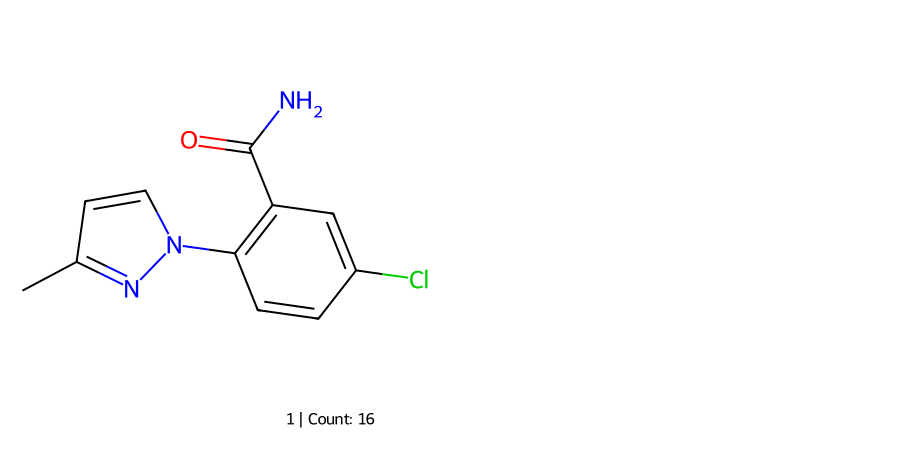

In [28]:
raw_data = "[16, 0, 0, 0, 0]|0|[('[H][c]1[c]([H])[c](-[n]2[n][c]([C]([H])([H])[H])[c]([H])[c]2[H])[c]([C](=[O])[N]([H])[H])[c]([H])[c]1[Cl]', 16, True)]"
show_nanogpt_predictions(raw_data)

Не удалось прочитать SMILES в Top-3


[17:29:10] Explicit valence for atom # 14 C, 5, is greater than permitted


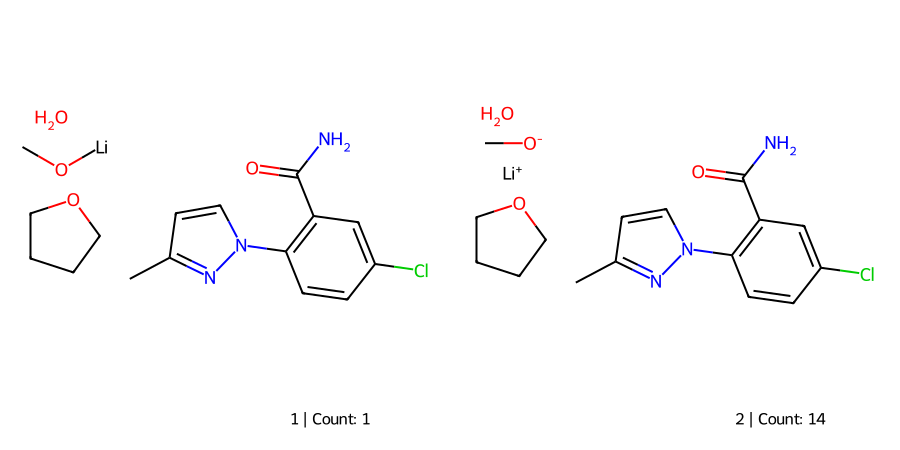

In [24]:
raw_data = "[14, 2, 0, 0, 0]|0|[('[H][C]([H])([H])[O][Li].[H][C]1([H])[O][C]([H])([H])[C]([H])([H])[C]1([H])[H].[H][O][H].[H][c]1[c]([H])[c](-[n]2[n][c]([C]([H])([H])[H])[c]([H])[c]2[H])[c]([C](=[O])[N]([H])[H])[c]([H])[c]1[Cl]', 1, True), ('[H][C]([H])([H])[O-].[H][C]1([H])[O][C]([H])([H])[C]([H])([H])[C]1([H])[H].[H][O][H].[H][c]1[c]([H])[c](-[n]2[n][c]([C]([H])([H])[H])[c]([H])[c]2[H])[c]([C](=[O])[N]([H])[H])[c]([H])[c]1[Cl].[Li+]', 14, True), ('[H][C]([H])([H])[O-].[H][C]1([H])[O][C]([H])([H])[C]([H])([H])[C]1([H])[H].[H][O][H].[H][c]1[c]([C]([H])([H])[H])[n][n]([C]2=[C+]([H])=[C+]([H])=[C]([Cl])[C-]([H])[C-]2[C](=[O])[N]([H])[H])[c]1[H].[Li+]', 1, True)]"
show_nanogpt_predictions(raw_data)

In [29]:
from rdkit import Chem

def prepare_for_flower_flower(smiles_string): #это из фловера в другой фловер
    mol = Chem.MolFromSmiles(smiles_string)
    if not mol:
        return "Ошибка: Невалидный SMILES"

    mol = Chem.AddHs(mol)
    Chem.Kekulize(mol, clearAromaticFlags=True)
    for i, atom in enumerate(mol.GetAtoms()):
        atom.SetAtomMapNum(i + 1)
    final_smiles = Chem.MolToSmiles(mol, kekuleSmiles=True)
    
    return final_smiles

In [30]:
input_smiles = "[H][C]([H])([H])[C]([H])([H])[O-].[H][C]1([H])[O][C]([H])([H])[C]([H])([H])[C]1([H])[H].[H][O][H].[H][c]1[c]([H])[c]([C]([O-])([O][C]([H])([H])[C]([H])([H])[H])[O+]([H])[H])[c]([H])[c]([H])[c]1[N]([H])[H].[Li+]"

prepared_output = prepare_for_flower_flower(input_smiles)
print(prepared_output)

[C:10]1([H:39])=[C:11]([H:40])[C:12]([C:13]([O-:14])([O:15][C:16]([C:17]([H:43])([H:44])[H:45])([H:41])[H:42])[O+:18]([H:46])[H:47])=[C:19]([H:48])[C:20]([H:49])=[C:21]1[N:22]([H:50])[H:51].[C:1]([C:2]([O-:3])([H:27])[H:28])([H:24])([H:25])[H:26].[C:4]1([H:29])([H:30])[O:5][C:6]([H:31])([H:32])[C:7]([H:33])([H:34])[C:8]1([H:35])[H:36].[Li+:23].[O:9]([H:37])[H:38]


In [68]:
from rdkit import Chem

def break_molecule_into_atoms(smiles):
    # 1. Загружаем молекулу и обязательно добавляем водороды
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return "Invalid SMILES"
    mol = Chem.AddHs(mol)
    
    # 2. Собираем список атомов с их маппингом
    atom_list = []
    for atom in mol.GetAtoms():
        symbol = atom.GetSymbol()
        # Используем существующий маппинг или создаем новый по порядку
        mapping = atom.GetAtomMapNum()
        if mapping == 0:
            mapping = atom.GetIdx() + 1
            
        # Формируем запись одинокого атома
        atom_list.append(f"[{symbol}:{mapping}]")
    
    # 3. Соединяем всё через точку (в терминах SMILES это несвязанные объекты)
    right_side = ".".join(atom_list)
    
    # 4. Формируем полную строку для входа во FlowER
    # Лево: Исходный SMILES (со связями)
    # Право: Те же атомы (без связей)
    left_side = Chem.MolToSmiles(mol, kekuleSmiles=True)
    
    return f"{left_side}>>{right_side}|1"

# Пример с Бензокаином
input_smiles = "[H][C]([H])([H])[C]([H])([H])[Cl].[H][O][C](=[O])[c]1[c]([H])[c]([H])[c]([N]([H])[H])[c]([H])[c]1[H]"
result = break_molecule_into_atoms(input_smiles)

print("Вход для FlowER (генеративный режим):")
print(result)

Вход для FlowER (генеративный режим):
[H]C([H])([H])C([H])([H])Cl.[H]OC(=O)C1=C([H])C([H])=C(N([H])[H])C([H])=C1[H]>>[C:1].[C:2].[Cl:3].[O:4].[C:5].[O:6].[C:7].[C:8].[C:9].[C:10].[N:11].[C:12].[C:13].[H:14].[H:15].[H:16].[H:17].[H:18].[H:19].[H:20].[H:21].[H:22].[H:23].[H:24].[H:25]|1


In [29]:
def make_no_bond_target(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    atoms = []
    for i, atom in enumerate(mol.GetAtoms()):
        symbol = atom.GetSymbol()
        atoms.append(f"[{symbol}:{i+1}]")
    
    return ".".join(atoms)

In [30]:
print(make_no_bond_target('[C:1]([C:2]1=[N:3][N:4]([C:7]2=[C:8]([C:14](=[O:15])[N:16]([H:25])[H:26])[C:9]([H:22])=[C:10]([Cl:13])[C:11]([H:23])=[C:12]2[H:24])[C:5]([H:20])=[C:6]1[H:21])([H:17])([H:18])[H:19]'))

[C:1].[C:2].[N:3].[N:4].[C:5].[C:6].[C:7].[O:8].[N:9].[C:10].[C:11].[Cl:12].[C:13].[C:14].[C:15].[C:16].[H:17].[H:18].[H:19].[H:20].[H:21].[H:22].[H:23].[H:24].[H:25].[H:26]


In [67]:
from rdkit import Chem

smi = "[H][C]([H])([H])[C]([H])([H])[Cl].[H][O][C](=[O])[c]1[c]([H])[c]([H])[c]([N]([H])[H])[c]([H])[c]1[H]"
mol = Chem.MolFromSmiles(smi)

if mol:
    mol = Chem.AddHs(mol, explicitOnly=False)
    for idx, atom in enumerate(mol.GetAtoms()):
        atom.SetAtomMapNum(idx + 1)
    
    mapped_smi = Chem.MolToSmiles(mol, isomericSmiles=False, allHsExplicit=True)
    
    final_string = f"{mapped_smi}>>{mapped_smi}|1"
    print(final_string)
else:
    print(f"Error: Invalid SMILES string '{smi}'")

[C:1]([C:2]([Cl:3])([H:17])[H:18])([H:14])([H:15])[H:16].[O:4]([C:5](=[O:6])[c:7]1[c:8]([H:20])[c:9]([H:21])[c:10]([N:11]([H:22])[H:23])[c:12]([H:24])[c:13]1[H:25])[H:19]>>[C:1]([C:2]([Cl:3])([H:17])[H:18])([H:14])([H:15])[H:16].[O:4]([C:5](=[O:6])[c:7]1[c:8]([H:20])[c:9]([H:21])[c:10]([N:11]([H:22])[H:23])[c:12]([H:24])[c:13]1[H:25])[H:19]|1


In [ ]:
print(mapped_smi)

[C:1]([C:2]([O:3][C:4](=[O:5])[c:6]1[c:7]([H:20])[c:8]([H:21])[c:9]([N:12]([H:24])[H:25])[c:10]([H:22])[c:11]1[H:23])([H:18])[H:19])([H:15])([H:16])[H:17].[Cl-:14].[O:13]([H:26])[H:27]
